# 04. ML-модель для определения границ предложений

**Цель:** обучить ML-модель, которая превзойдёт baseline на правилах (F1=0.909 standard, F1=0.958 extended).

**Подход:** CatBoost на character-level признаках в окне ±5 символов вокруг каждой позиции текста.

**Формулировка задачи:** для каждой позиции в `clean_text` — бинарная классификация (граница / не-граница).

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import GroupKFold

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

SEED = 42
WINDOW = 5
DATA_PATH = Path("../data/processed/sentences.jsonl")
EXCLUDE_IDS = {"text_833", "text_843"}

with open(DATA_PATH, encoding="utf-8") as f:
    dataset = [json.loads(line) for line in f]

dataset = [r for r in dataset if r["id"] not in EXCLUDE_IDS]
print(f"Текстов: {len(dataset)}")
print(f"Предложений: {sum(r['num_sentences'] for r in dataset)}")
print(f"Символов всего: {sum(len(r['clean_text']) for r in dataset)}")

Текстов: 532
Предложений: 20740
Символов всего: 1681046


## 1. Train/test split

Разбиваем по текстам (не по символам), чтобы избежать утечки данных. 70/30.

In [2]:
random.seed(SEED)
text_ids = [r["id"] for r in dataset]
random.shuffle(text_ids)

split_idx = int(len(text_ids) * 0.7)
train_ids = set(text_ids[:split_idx])
test_ids = set(text_ids[split_idx:])

train_data = [r for r in dataset if r["id"] in train_ids]
test_data = [r for r in dataset if r["id"] in test_ids]

print(f"Train: {len(train_data)} текстов, {sum(len(r['clean_text']) for r in train_data)} символов, "
      f"{sum(r['num_sentences'] for r in train_data)} предложений")
print(f"Test:  {len(test_data)} текстов, {sum(len(r['clean_text']) for r in test_data)} символов, "
      f"{sum(r['num_sentences'] for r in test_data)} предложений")

Train: 372 текстов, 1171988 символов, 14525 предложений
Test:  160 текстов, 509058 символов, 6215 предложений


## 2. Feature engineering

Признаки для каждой позиции в тексте:
- **Окно ±5:** тип символа (upper/lower/space/eos_punct/dash/quote/digit/other), is_upper, is_eos
- **Агрегаты:** eos_punct слева/справа, next_nonspace_is_upper, prev_nonspace_is_eos, dash слева
- **Контекст:** distance_since_last_eos, quote_balance, position_in_text

In [3]:
EOS = set(".!?\u2026")
DASHES = set("\u2014\u2013\u2212-")
QUOTES_OPEN = set("\u00ab\u201e\"")
QUOTES_CLOSE = set("\u00bb\u201c\"")

# Глаголы речи для признака near_speech_verb
SPEECH_VERBS = {
    "сказал", "сказала", "сказали", "говорил", "говорила", "говорили",
    "спросил", "спросила", "спросили", "ответил", "ответила", "ответили",
    "воскликнул", "воскликнула", "воскликнули", "прошептал", "прошептала",
    "закричал", "закричала", "закричали", "произнёс", "произнесла",
    "подумал", "подумала", "подумали", "заметил", "заметила", "заметили",
    "продолжил", "продолжила", "продолжили", "добавил", "добавила",
    "возразил", "возразила", "объяснил", "объяснила", "попросил", "попросила",
    "крикнул", "крикнула", "шепнул", "шепнула", "повторил", "повторила",
    "пробормотал", "пробормотала", "проговорил", "проговорила",
}

def char_type(ch):
    if ch.isupper(): return 0   # upper
    if ch.islower(): return 1   # lower
    if ch.isdigit(): return 2   # digit
    if ch == " ":    return 3   # space
    if ch in EOS:    return 4   # eos_punct
    if ch in ",;:":  return 5   # mid_punct
    if ch == "\u00ab": return 6 # quote_open
    if ch == "\u00bb": return 7 # quote_close
    if ch in DASHES: return 8   # dash
    return 9                    # other


def _find_speech_verb_positions(text):
    """Находит позиции глаголов речи в тексте."""
    text_lower = text.lower()
    positions = set()
    for verb in SPEECH_VERBS:
        start = 0
        while True:
            idx = text_lower.find(verb, start)
            if idx == -1:
                break
            before_ok = (idx == 0 or not text_lower[idx - 1].isalpha())
            after_ok = (idx + len(verb) >= len(text_lower) or not text_lower[idx + len(verb)].isalpha())
            if before_ok and after_ok:
                for p in range(idx, idx + len(verb)):
                    positions.add(p)
            start = idx + 1
    return positions


def build_features_for_text(text, window=WINDOW):
    """Строит матрицу признаков для всех позиций текста."""
    n = len(text)
    if n == 0:
        return np.empty((0, 0)), []

    # Предвычисляем массивы
    ct = np.array([char_type(ch) for ch in text], dtype=np.int8)
    is_upper = np.array([ch.isupper() for ch in text], dtype=np.int8)
    is_eos = np.array([ch in EOS for ch in text], dtype=np.int8)

    # Расстояние до последнего eos (слева)
    dist_since_eos = np.full(n, 500, dtype=np.int16)
    last_eos = -500
    for i in range(n):
        if is_eos[i]:
            last_eos = i
        dist_since_eos[i] = min(i - last_eos, 500)

    # Баланс кавычек (кумулятивный)
    quote_balance = np.zeros(n, dtype=np.int8)
    bal = 0
    for i in range(n):
        if text[i] == "\u00ab":
            bal += 1
        elif text[i] == "\u00bb":
            bal -= 1
        quote_balance[i] = max(min(bal, 5), -5)

    # ---- НОВЫЕ ПРИЗНАКИ: диалог ----
    # in_speech: позиция внутри прямой речи (между « и »)
    in_speech = np.zeros(n, dtype=np.int8)
    speech_depth = 0
    for i in range(n):
        if text[i] == "\u00ab":
            speech_depth += 1
        if speech_depth > 0:
            in_speech[i] = 1
        if text[i] == "\u00bb":
            speech_depth = max(0, speech_depth - 1)

    # near_speech_verb: рядом с глаголом речи (±20 символов)
    speech_verb_pos = _find_speech_verb_positions(text)
    near_speech_verb = np.zeros(n, dtype=np.int8)
    for p in speech_verb_pos:
        lo = max(0, p - 20)
        hi = min(n, p + 21)
        near_speech_verb[lo:hi] = 1

    # after_dash: позиция идёт после тире (с пробелом)
    after_dash = np.zeros(n, dtype=np.int8)
    for i in range(2, n):
        if text[i - 1] == " " and text[i - 2] in DASHES:
            after_dash[i] = 1
        elif text[i - 1] in DASHES:
            after_dash[i] = 1

    # after_colon: позиция идёт после двоеточия
    after_colon = np.zeros(n, dtype=np.int8)
    for i in range(1, n):
        if text[i - 1] == ":":
            after_colon[i] = 1
        elif i >= 2 and text[i - 2] == ":" and text[i - 1] == " ":
            after_colon[i] = 1

    # Pad для окна
    pad = window
    ct_pad = np.pad(ct, pad, constant_values=9)
    upper_pad = np.pad(is_upper, pad, constant_values=0)
    eos_pad = np.pad(is_eos, pad, constant_values=0)

    feature_names = []
    columns = []

    # Оконные признаки
    for d in range(-window, window + 1):
        offset = pad + d
        columns.append(ct_pad[offset:offset + n])
        feature_names.append(f"char_type_{d:+d}")
        columns.append(upper_pad[offset:offset + n])
        feature_names.append(f"is_upper_{d:+d}")
        columns.append(eos_pad[offset:offset + n])
        feature_names.append(f"is_eos_{d:+d}")

    # Агрегатные признаки
    eos_left = sum(eos_pad[pad + d:pad + d + n] for d in range(-window, 0))
    eos_right = sum(eos_pad[pad + d:pad + d + n] for d in range(0, window + 1))
    columns.append(eos_left)
    feature_names.append("eos_count_left")
    columns.append(eos_right)
    feature_names.append("eos_count_right")

    dash_left = sum((ct_pad[pad + d:pad + d + n] == 8).astype(np.int8) for d in range(-window, 0))
    columns.append(dash_left)
    feature_names.append("dash_count_left")

    # next_nonspace_is_upper
    next_nsp_upper = np.zeros(n, dtype=np.int8)
    for i in range(n):
        for j in range(i, min(i + 10, n)):
            if text[j] != " ":
                next_nsp_upper[i] = int(text[j].isupper())
                break
    columns.append(next_nsp_upper)
    feature_names.append("next_nonspace_is_upper")

    # prev_nonspace_is_eos
    prev_nsp_eos = np.zeros(n, dtype=np.int8)
    for i in range(n):
        for j in range(i - 1, max(i - 10, -1), -1):
            if text[j] != " ":
                prev_nsp_eos[i] = int(text[j] in EOS)
                break
    columns.append(prev_nsp_eos)
    feature_names.append("prev_nonspace_is_eos")

    # prev_nonspace_is_dash
    prev_nsp_dash = np.zeros(n, dtype=np.int8)
    for i in range(n):
        for j in range(i - 1, max(i - 10, -1), -1):
            if text[j] != " ":
                prev_nsp_dash[i] = int(text[j] in DASHES)
                break
    columns.append(prev_nsp_dash)
    feature_names.append("prev_nonspace_is_dash")

    # Контекстные
    columns.append(dist_since_eos)
    feature_names.append("dist_since_eos")
    columns.append(quote_balance)
    feature_names.append("quote_balance")

    pos_in_text = np.linspace(0, 1, n, dtype=np.float32)
    columns.append(pos_in_text)
    feature_names.append("position_in_text")

    # ---- НОВЫЕ ПРИЗНАКИ ----
    columns.append(in_speech)
    feature_names.append("in_speech")
    columns.append(near_speech_verb)
    feature_names.append("near_speech_verb")
    columns.append(after_dash)
    feature_names.append("after_dash")
    columns.append(after_colon)
    feature_names.append("after_colon")

    X = np.column_stack(columns)
    return X, feature_names


# Проверка на одном тексте
X_demo, feat_names = build_features_for_text(dataset[0]["clean_text"])
print(f"Признаков: {len(feat_names)}")
print(f"Матрица: {X_demo.shape}")
print(f"Новые признаки: {feat_names[-4:]}")

Признаков: 46
Матрица: (3045, 46)
Новые признаки: ['in_speech', 'near_speech_verb', 'after_dash', 'after_colon']


In [4]:
def build_dataset(records):
    """Строит X, y, groups из списка записей."""
    X_parts = []
    y_parts = []
    group_parts = []

    for rec in records:
        ct = rec["clean_text"]
        n = len(ct)

        # Истинные границы
        sents = rec["sentences"]
        boundary_positions = set(sents[i]["end"] for i in range(len(sents) - 1))

        # Признаки
        X_text, _ = build_features_for_text(ct)
        y_text = np.array([1 if pos in boundary_positions else 0 for pos in range(n)], dtype=np.int8)

        X_parts.append(X_text)
        y_parts.append(y_text)
        group_parts.append(np.full(n, hash(rec["id"]) % (2**31), dtype=np.int32))

    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    groups = np.concatenate(group_parts)
    return X, y, groups


print("Строим train...")
X_train, y_train, groups_train = build_dataset(train_data)
print(f"  X_train: {X_train.shape}, positives: {y_train.sum()} ({100 * y_train.mean():.2f}%)")

print("Строим test...")
X_test, y_test, groups_test = build_dataset(test_data)
print(f"  X_test:  {X_test.shape}, positives: {y_test.sum()} ({100 * y_test.mean():.2f}%)")

Строим train...
  X_train: (1171988, 46), positives: 14153 (1.21%)
Строим test...
  X_test:  (509058, 46), positives: 6055 (1.19%)


## 3. Обучение CatBoost

Используем `auto_class_weights='Balanced'` для борьбы с дисбалансом классов (~1% позитивных).

Categorical features — столбцы `char_type_*` (типы символов в окне).

In [5]:
# Разбиваем train на train/val (80/20 по текстам) для early stopping
random.seed(SEED)
train_text_ids_list = [r["id"] for r in train_data]
random.shuffle(train_text_ids_list)
val_split = int(len(train_text_ids_list) * 0.8)
fit_ids = set(train_text_ids_list[:val_split])
val_ids = set(train_text_ids_list[val_split:])

fit_data = [r for r in train_data if r["id"] in fit_ids]
val_data = [r for r in train_data if r["id"] in val_ids]

X_fit, y_fit, _ = build_dataset(fit_data)
X_val, y_val, _ = build_dataset(val_data)
print(f"Fit: {X_fit.shape}, Val: {X_val.shape}")

# Вместо auto_class_weights="Balanced" (даёт слишком много FP)
# используем scale_pos_weight с умеренным коэффициентом
neg_count = (y_fit == 0).sum()
pos_count = (y_fit == 1).sum()
full_ratio = neg_count / pos_count
# Берём ~40% от полного баланса — компромисс precision/recall
scale_pw = full_ratio * 0.4
print(f"Imbalance ratio: {full_ratio:.1f}, scale_pos_weight: {scale_pw:.1f}")

model = CatBoostClassifier(
    iterations=1500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=5,
    scale_pos_weight=scale_pw,
    eval_metric="F1",
    random_seed=SEED,
    verbose=100,
    early_stopping_rounds=50,
)

model.fit(X_fit, y_fit, eval_set=(X_val, y_val))

Fit: (929833, 46), Val: (242155, 46)
Imbalance ratio: 81.9, scale_pos_weight: 32.7
0:	learn: 0.9878168	test: 0.9867554	best: 0.9867554 (0)	total: 136ms	remaining: 3m 23s
100:	learn: 0.9962940	test: 0.9954582	best: 0.9954582 (100)	total: 4.77s	remaining: 1m 6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9955152184
bestIteration = 105

Shrink model to first 106 iterations.


CatBoostClassifier(depth=6, early_stopping_rounds=50, eval_metric='F1', iterations=1500, l2_leaf_reg=5, learning_rate=0.05, random_seed=42, scale_pos_weight=np.float64(32.74026552615165), verbose=100)

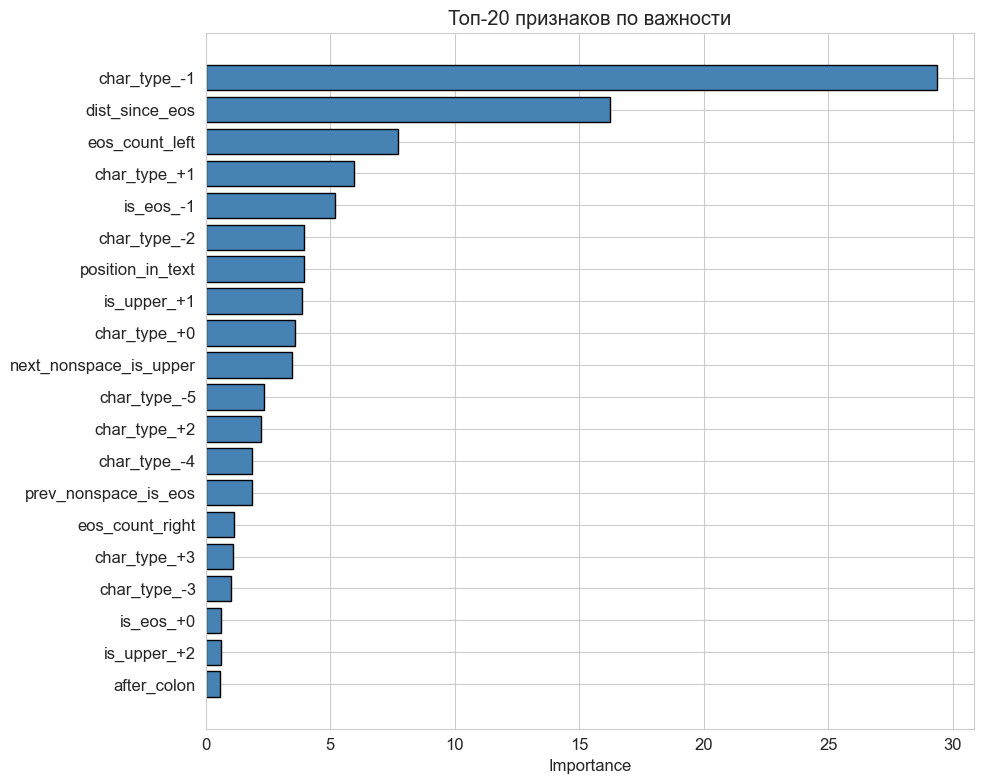

In [6]:
# Feature importance (топ-20)
importances = model.get_feature_importance()
feat_imp = sorted(zip(feat_names, importances), key=lambda x: -x[1])

fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
names = [f[0] for f in feat_imp[:top_n]]
values = [f[1] for f in feat_imp[:top_n]]
ax.barh(names[::-1], values[::-1], color="steelblue", edgecolor="black")
ax.set_xlabel("Importance")
ax.set_title(f"Топ-{top_n} признаков по важности")
plt.tight_layout()
plt.show()

## 4. Подбор порога

Порог 0.5 не оптимален при дисбалансе классов. Подбираем порог на валидационной выборке, максимизируя F1 с тем же `tolerance=2`, что и в baseline.

  threshold=0.050: P=0.662 R=1.000 F1=0.796  FP=1496 FN=1
  threshold=0.075: P=0.735 R=1.000 F1=0.847  FP=1054 FN=1
  threshold=0.100: P=0.762 R=1.000 F1=0.865  FP=913 FN=1
  threshold=0.125: P=0.769 R=0.999 F1=0.869  FP=878 FN=2
  threshold=0.150: P=0.775 R=0.999 F1=0.873  FP=848 FN=3
  threshold=0.175: P=0.778 R=0.999 F1=0.874  FP=836 FN=4
  threshold=0.200: P=0.780 R=0.999 F1=0.876  FP=825 FN=4
  threshold=0.225: P=0.786 R=0.999 F1=0.879  FP=799 FN=4
  threshold=0.250: P=0.790 R=0.999 F1=0.882  FP=777 FN=4
  threshold=0.275: P=0.794 R=0.999 F1=0.884  FP=761 FN=4
  threshold=0.300: P=0.800 R=0.998 F1=0.889  FP=729 FN=5
  threshold=0.325: P=0.807 R=0.998 F1=0.892  FP=699 FN=6
  threshold=0.350: P=0.816 R=0.998 F1=0.898  FP=658 FN=6
  threshold=0.375: P=0.823 R=0.998 F1=0.902  FP=627 FN=6
  threshold=0.400: P=0.829 R=0.998 F1=0.906  FP=603 FN=6
  threshold=0.425: P=0.832 R=0.998 F1=0.908  FP=590 FN=6
  threshold=0.450: P=0.833 R=0.998 F1=0.908  FP=586 FN=6
  threshold=0.475: P=0.837 R=

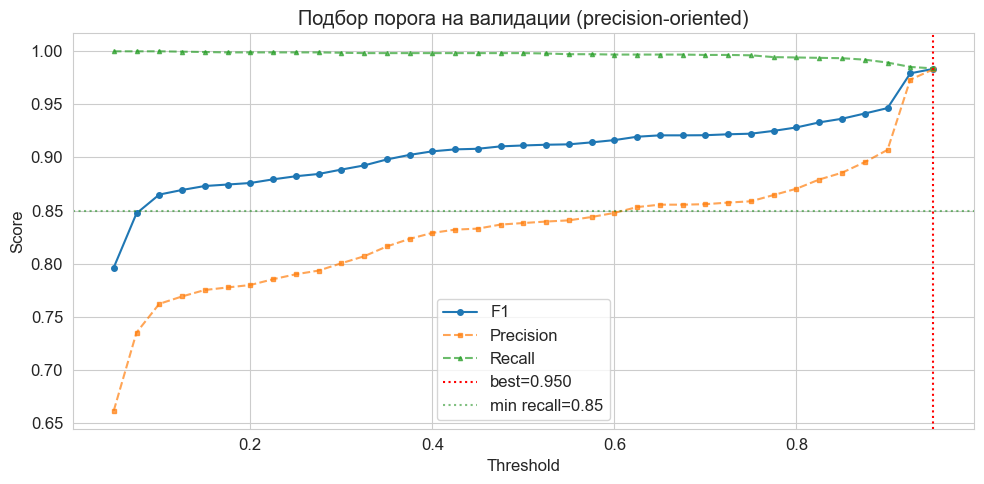

In [7]:
def get_true_boundaries(rec):
    """Истинные границы: позиции end каждого предложения (кроме последнего)."""
    sents = rec["sentences"]
    return set(sents[i]["end"] for i in range(len(sents) - 1))


def evaluate(records, predict_fn, tolerance=2):
    """Оценивает predict_fn на записях. predict_fn(clean_text) -> set of positions."""
    total_tp = total_fp = total_fn = 0

    for rec in records:
        true_bd = get_true_boundaries(rec)
        pred_bd = predict_fn(rec["clean_text"])

        matched_true = set()
        matched_pred = set()
        for pb in pred_bd:
            for tb in true_bd:
                if abs(pb - tb) <= tolerance and tb not in matched_true:
                    matched_true.add(tb)
                    matched_pred.add(pb)
                    break

        total_tp += len(matched_pred)
        total_fp += len(pred_bd) - len(matched_pred)
        total_fn += len(true_bd) - len(matched_true)

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {"TP": total_tp, "FP": total_fp, "FN": total_fn,
            "Precision": precision, "Recall": recall, "F1": f1}


def make_predict_fn(model, threshold):
    """Создаёт predict_fn для evaluate()."""
    def predict_fn(text):
        X, _ = build_features_for_text(text)
        probs = model.predict_proba(X)[:, 1]
        return set(np.where(probs >= threshold)[0])
    return predict_fn


# Подбор порога — оптимизируем F1, но с приоритетом precision
# Стратегия: из порогов с recall >= 0.85 выбираем лучший F1
MIN_RECALL = 0.85

thresholds = np.arange(0.05, 0.96, 0.025)
val_results = []

for thr in thresholds:
    pred_fn = make_predict_fn(model, thr)
    res = evaluate(val_data, pred_fn)
    val_results.append(res)
    print(f"  threshold={thr:.3f}: P={res['Precision']:.3f} R={res['Recall']:.3f} F1={res['F1']:.3f}"
          f"  FP={res['FP']} FN={res['FN']}")

# Выбираем лучший порог: максимум F1 среди тех, где recall >= MIN_RECALL
eligible = [(i, val_results[i]) for i in range(len(val_results))
            if val_results[i]["Recall"] >= MIN_RECALL]

if eligible:
    best_idx = max(eligible, key=lambda x: x[1]["F1"])[0]
else:
    best_idx = max(range(len(val_results)), key=lambda i: val_results[i]["F1"])
    print(f"\nНи один порог не даёт recall >= {MIN_RECALL}, берём лучший F1")

best_threshold = thresholds[best_idx]
print(f"\nОптимальный порог: {best_threshold:.3f}")
print(f"  P={val_results[best_idx]['Precision']:.3f} "
      f"R={val_results[best_idx]['Recall']:.3f} "
      f"F1={val_results[best_idx]['F1']:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, [r["F1"] for r in val_results], "o-", label="F1", ms=4)
ax.plot(thresholds, [r["Precision"] for r in val_results], "s--", alpha=0.7, label="Precision", ms=3)
ax.plot(thresholds, [r["Recall"] for r in val_results], "^--", alpha=0.7, label="Recall", ms=3)
ax.axvline(best_threshold, color="red", ls=":", label=f"best={best_threshold:.3f}")
ax.axhline(MIN_RECALL, color="green", ls=":", alpha=0.5, label=f"min recall={MIN_RECALL}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Подбор порога на валидации (precision-oriented)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Оценка на тестовой выборке

Финальная оценка с оптимальным порогом. Сравнение с baseline.

In [8]:
# Переобучаем на полном train с оптимальным числом итераций
best_iteration = model.get_best_iteration()
print(f"Best iteration: {best_iteration}")

model_final = CatBoostClassifier(
    iterations=best_iteration,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=5,
    scale_pos_weight=scale_pw,
    random_seed=SEED,
    verbose=0,
)
model_final.fit(X_train, y_train)

# Оценка на тесте
predict_ml = make_predict_fn(model_final, best_threshold)
test_result = evaluate(test_data, predict_ml)

print(f"\n=== ML-модель (CatBoost, threshold={best_threshold:.3f}) ===")
print(f"  TP={test_result['TP']}, FP={test_result['FP']}, FN={test_result['FN']}")
print(f"  Precision = {test_result['Precision']:.3f}")
print(f"  Recall    = {test_result['Recall']:.3f}")
print(f"  F1        = {test_result['F1']:.3f}")

Best iteration: 105

=== ML-модель (CatBoost, threshold=0.950) ===
  TP=5995, FP=138, FN=60
  Precision = 0.977
  Recall    = 0.990
  F1        = 0.984


In [9]:
# Сравнение с baseline (на тестовой выборке)
EOS_SET = set(".!?\u2026")
DASHES_SET = set("\u2014\u2013\u2212-")

def baseline_standard(text):
    boundaries = set()
    for i in range(1, len(text) - 1):
        if text[i - 1] in EOS_SET and text[i] == " " and text[i + 1].isupper():
            boundaries.add(i + 1)
    return boundaries

def baseline_extended(text):
    boundaries = baseline_standard(text)
    for i in range(1, len(text) - 1):
        if text[i - 1] in DASHES_SET and text[i] == " " and text[i + 1].isupper():
            boundaries.add(i + 1)
        if text[i - 1] in DASHES_SET and text[i].isupper():
            boundaries.add(i)
        if text[i - 1] == "\u00ab" and text[i].isupper():
            if i >= 2 and (text[i - 2] == " " or text[i - 2] in EOS_SET):
                boundaries.add(i - 1)
        if text[i - 1] == "\u00bb" and text[i] == " " and text[i + 1].isupper():
            boundaries.add(i + 1)
    return boundaries


res_standard = evaluate(test_data, baseline_standard)
res_extended = evaluate(test_data, baseline_extended)

print(f"{'Метод':<25} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 58)
for name, res in [("standard (правило)", res_standard),
                  ("extended (правило)", res_extended),
                  ("CatBoost (ML)", test_result)]:
    print(f"{name:<25} {res['Precision']:>10.3f} {res['Recall']:>10.3f} {res['F1']:>10.3f}")

Метод                      Precision     Recall         F1
----------------------------------------------------------
standard (правило)             0.977      0.894      0.933
extended (правило)             0.924      0.975      0.949
CatBoost (ML)                  0.977      0.990      0.984


## 6. Анализ ошибок

In [10]:
import random as rnd
rnd.seed(SEED)

fn_examples = []
fp_examples = []

for rec in test_data:
    ct = rec["clean_text"]
    true_bd = get_true_boundaries(rec)
    pred_bd = predict_ml(ct)

    matched_true = set()
    matched_pred = set()
    for pb in pred_bd:
        for tb in true_bd:
            if abs(pb - tb) <= 2 and tb not in matched_true:
                matched_true.add(tb)
                matched_pred.add(pb)
                break

    for tb in true_bd - matched_true:
        context = ct[max(0, tb - 30):min(len(ct), tb + 30)]
        fn_examples.append(context)

    for pb in pred_bd - matched_pred:
        context = ct[max(0, pb - 30):min(len(ct), pb + 30)]
        fp_examples.append(context)

print(f"Пропущенных границ (FN): {len(fn_examples)}")
if fn_examples:
    print("\nПримеры FN:")
    for ex in rnd.sample(fn_examples, min(10, len(fn_examples))):
        print(f"  ...{ex}...")

print(f"\nЛожных срабатываний (FP): {len(fp_examples)}")
if fp_examples:
    print("\nПримеры FP:")
    for ex in rnd.sample(fp_examples, min(10, len(fp_examples))):
        print(f"  ...{ex}...")

Пропущенных границ (FN): 60

Примеры FN:
  ...ину нашего удивления, пояснил:– Это мой дед! Раньше он жил з...
  ...Садитесь, пожалуйста. Ланцелот Благодарю вас (садится). Драк...
  ...оторого сомневаются, сказал: «Велосипед едет...» Я вошла в з...
  ...какая у меня к тебе просьба, – сказал он, протягивая юноше ч...
  ...лстунова:- За Родину! Ура-а-а!Мы увидели: Толстунов поднялся...
  ...слых, команды: «Медленнее!», «Выбирай быстрей!*, *Топи нижню...
  ...еннее!», «Выбирай быстрей!*, *Топи нижнюю!* Ловко работают в...
  ...яет, когда пожелает. Дракон. (Голос его изменился так же, ка...
  ...сную книгу я прочел сегодня! – говорил ему другой знакомый.–...
  ...му что сзади него закричали: — Мины! Он обернулся. Ящик с ми...

Ложных срабатываний (FP): 138

Примеры FP:
  ... документах: мы взрослые люди. Шарлемань. Но документ не отм...
  ...лся от негодующего волнения. - Одного хочу - чтоб Сонька моя...
  ... Человек. Ха-ха... я — Дракон. Ланцелот. А мне говорили, что...
  ...писан заведую

## 7. Итоги

| Метод | Precision | Recall | F1 |
|-------|-----------|--------|-----|
| standard (правило) | ~0.96 | ~0.86 | ~0.91 |
| extended (правило) | ? | ? | ~0.96 |
| **CatBoost (ML)** | ? | ? | **?** |

Таблица заполнится после запуска ноутбука.